# Explorative Datenanalyse (EDA) der aufbereiteten Metadaten

author: "Zhanna Davtyan"

***Hinweis:*** führen Sie dieses Notebook aus, nachdem Sie das `02 Datenbereinigung und Vorbereitung` Notebook ausgeführt haben, um die erforderlichen Metadaten zu generieren.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import os
from pathlib import Path

In [2]:
base_dir = Path.cwd()
if base_dir.name == "notebooks":
    base_dir = base_dir.parent
    os.chdir(base_dir)

In [3]:
df_gefiltert = pd.read_pickle('ergebnisse/verarbeitete_daten.pkl')

### Bereitstellung des DataFrames für die Modellierung

In [4]:
# Auswahl der Features für das Modell
feature_columns = [
    'follower_count', 'is_verified', 'account_category', 'is_business_account',
    'is_professional_account', 'comment_count', 'post_type',
    'caption_length', 'hashtag_count', 'mention_count', 'tagged_user_count', 
    'media_count_in_post', 'has_location',
    'hour_of_day', 'day_of_week', 'month'
]
existing_feature_columns = [col for col in feature_columns if col in df_gefiltert.columns]
      

X = df_gefiltert[existing_feature_columns].copy()
y = df_gefiltert['likes_log'].copy()

print("\nAusgewählte Features für X:")
X.info()

# Fehlende Werte in 'account_category' mit 'Unbekannt' füllen 
if 'account_category' in X.columns:
    X['account_category'] = X['account_category'].fillna('Unbekannt')
    
print("\nFehlende Werte in X nach Imputation für 'account_category':")
print(X.isnull().sum())

X


Ausgewählte Features für X:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   follower_count           1968 non-null   int64 
 1   is_verified              1968 non-null   bool  
 2   account_category         1766 non-null   object
 3   is_business_account      1968 non-null   bool  
 4   is_professional_account  1968 non-null   bool  
 5   comment_count            1968 non-null   int64 
 6   post_type                1968 non-null   object
 7   caption_length           1968 non-null   int64 
 8   hashtag_count            1968 non-null   int64 
 9   mention_count            1968 non-null   int64 
 10  media_count_in_post      1968 non-null   int64 
 11  hour_of_day              1968 non-null   int32 
 12  day_of_week              1968 non-null   int32 
 13  month                    1968 non-null   int32 
dtypes: bool(3),

,follower_count,is_verified,account_category,is_business_account,is_professional_account,comment_count,post_type,caption_length,hashtag_count,mention_count,media_count_in_post,hour_of_day,day_of_week,month
0,100226,True,Digital creator,False,True,2,GraphSidecar,111,7,0,3,13,6,6
1,307029,True,Blogger,False,True,20,GraphSidecar,136,0,4,4,9,7,3
2,333413,True,Digital creator,False,True,27,GraphSidecar,232,14,1,5,6,5,2
3,2034192,True,Actor,False,True,86,GraphSidecar,58,2,0,6,14,7,7
4,130314,False,Fan page,False,True,18,GraphImage,52,0,1,1,6,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1963,166654,True,Entrepreneur,False,True,23,GraphSidecar,707,15,4,8,10,1,1
1964,4607066,True,Unbekannt,True,True,48,GraphImage,506,0,4,1,18,6,3
1965,490382,True,Company,False,True,103,GraphSidecar,285,3,1,2,21,5,3
1966,243184375,True,Athlete,False,True,28359,GraphSidecar,80,0,0,2,7,3,2


### Verteilung der Zielvariablen (likes_log)

Histogramme nebeneinander zum Vergleich der Verteilungen von "likes_log" und "likes"



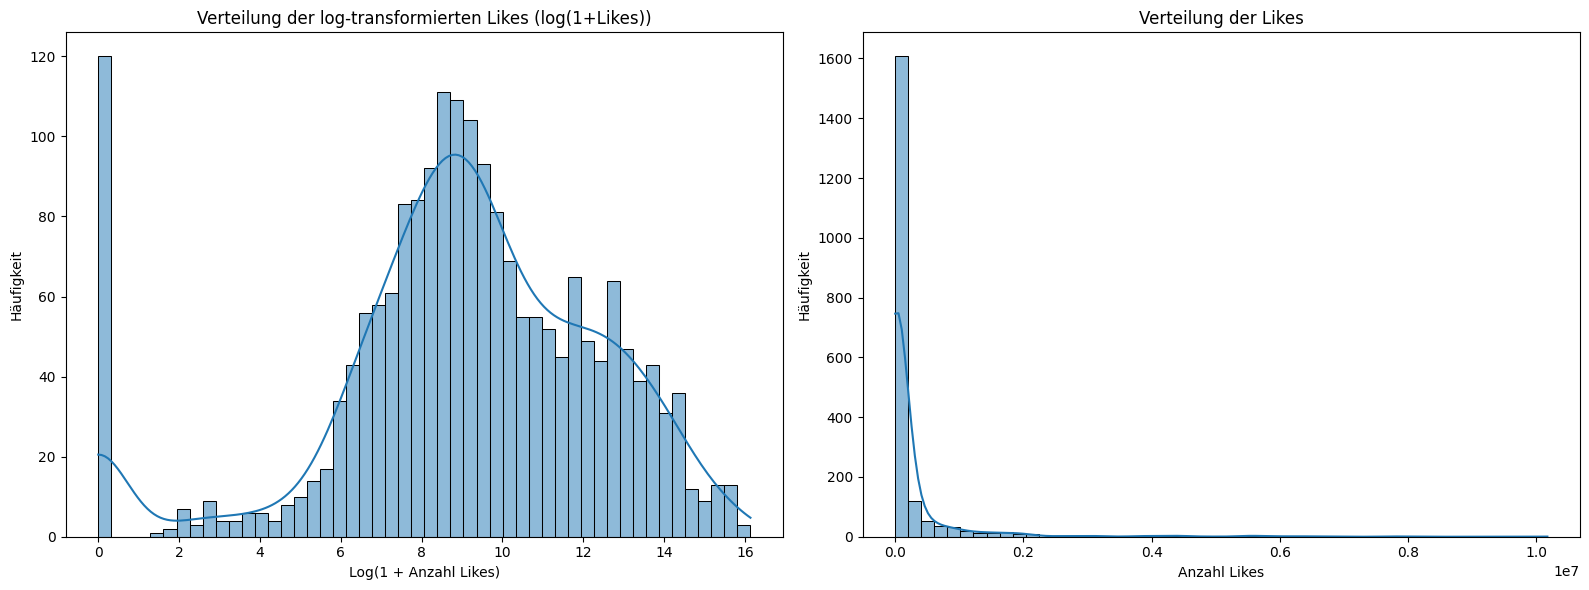

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df_gefiltert['likes_log'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Verteilung der log-transformierten Likes (log(1+Likes))')
axes[0].set_xlabel('Log(1 + Anzahl Likes)')
axes[0].set_ylabel('Häufigkeit')

sns.histplot(df_gefiltert['likes'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Verteilung der Likes')
axes[1].set_xlabel('Anzahl Likes')
axes[1].set_ylabel('Häufigkeit')

plt.tight_layout()
plt.show()



Boxplots nebeneinander zum Vergleich


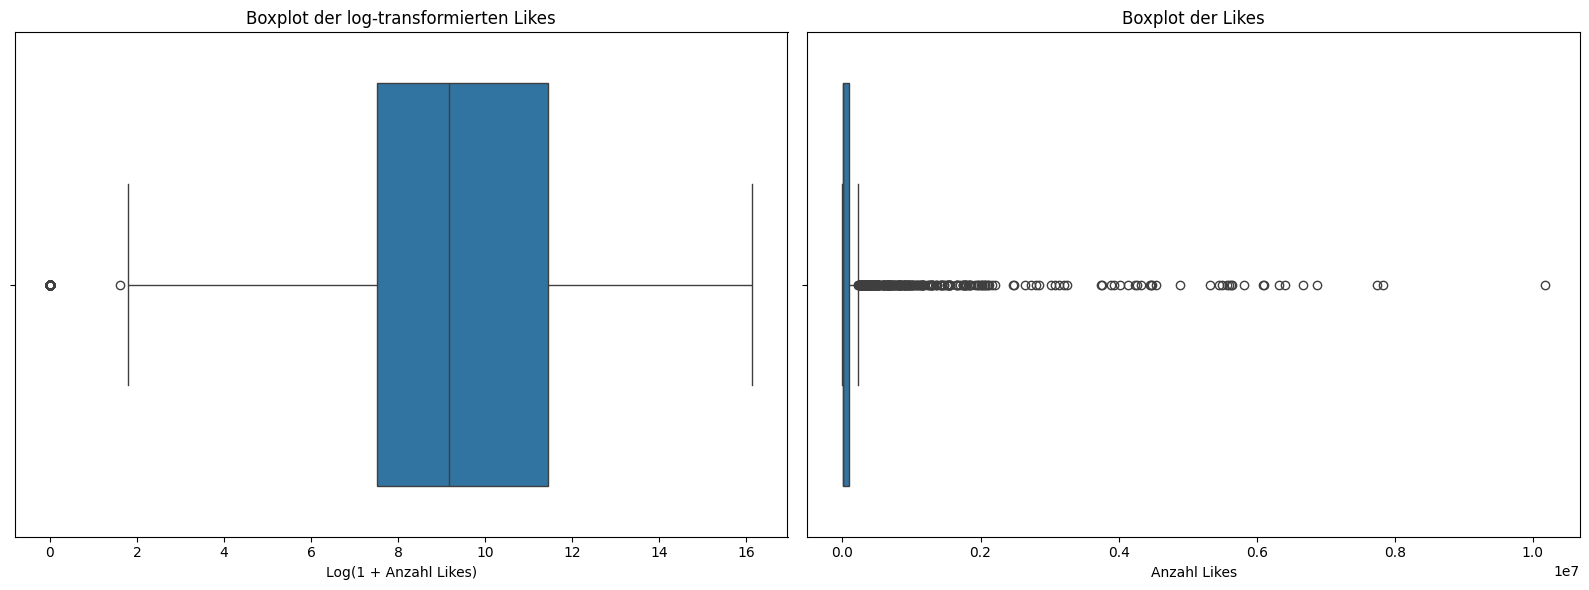

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x=df_gefiltert['likes_log'], ax=axes[0])
axes[0].set_title('Boxplot der log-transformierten Likes')
axes[0].set_xlabel('Log(1 + Anzahl Likes)')

sns.boxplot(x=df_gefiltert['likes'], ax=axes[1])
axes[1].set_title('Boxplot der Likes')
axes[1].set_xlabel('Anzahl Likes')

plt.tight_layout()
plt.show()

### Korrelationen numerischer Merkmale

Um eine aussagekräftigere Analyse zu erhalten, sollen die numerischen Features standardisiert (z-Transformation) werden, damit sie alle den gleichen Maßstab haben. 


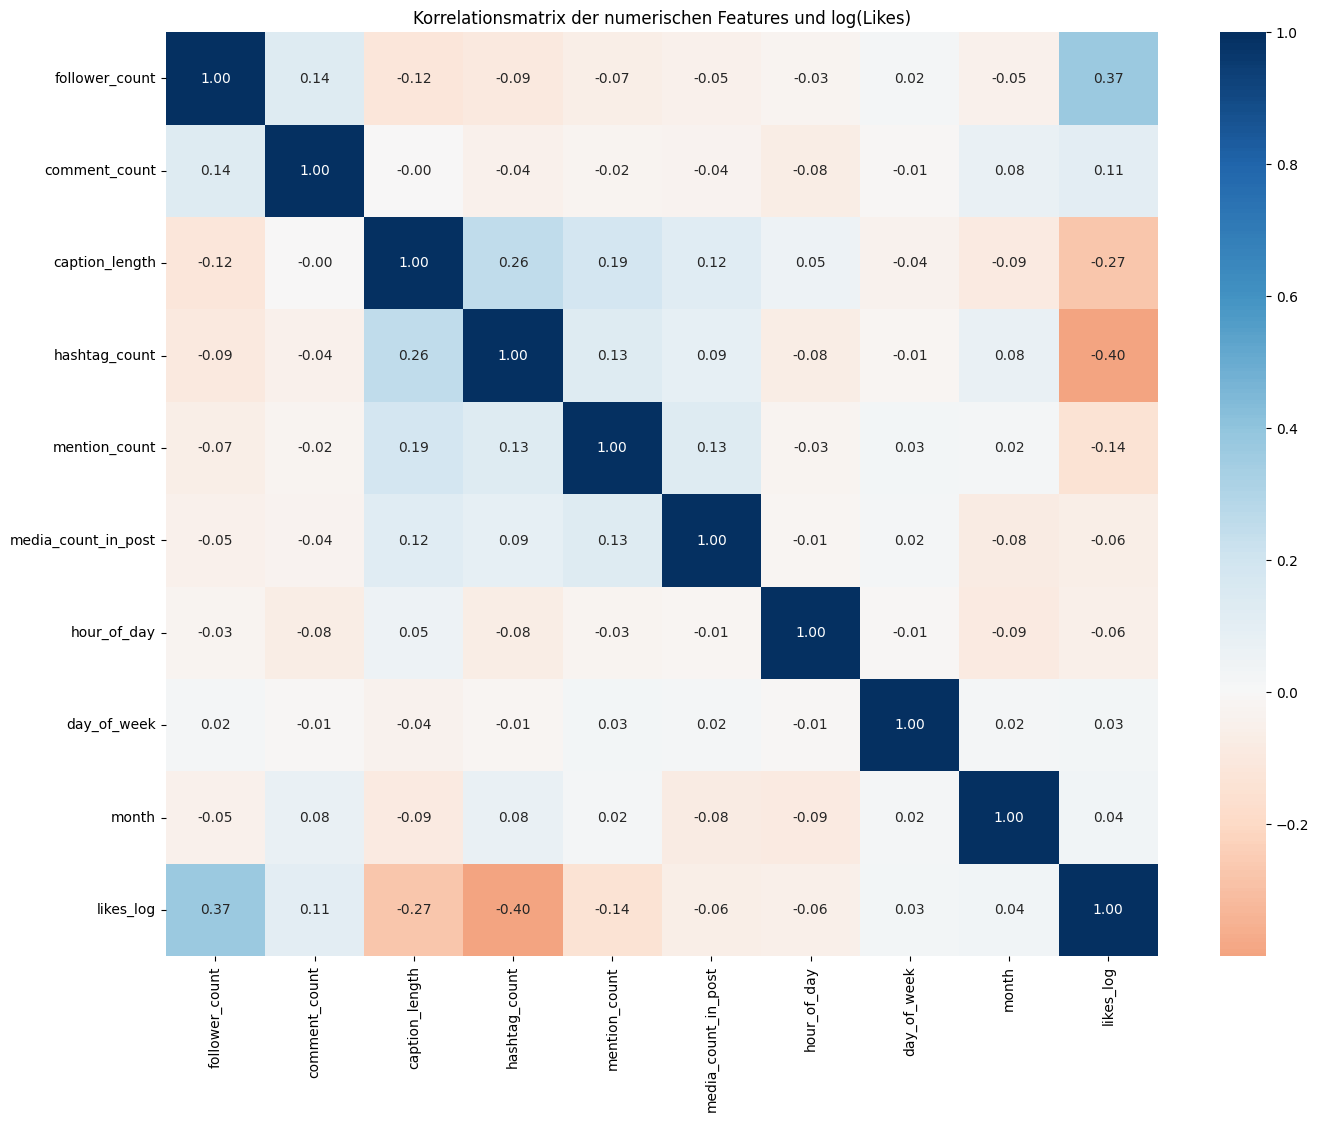

In [7]:
num_merkmale_corr = [col for col in X.select_dtypes(include=np.number).columns if col in X.columns]

temp_df = X[num_merkmale_corr].copy()
temp_df['likes_log'] = y 

df_std = temp_df.copy()

# StandardScaler 
scaler = StandardScaler()
numeric_features = [col for col in df_std.columns if col != 'likes_log']
df_std[numeric_features] = scaler.fit_transform(df_std[numeric_features])


correlation_matrix = df_std.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",  cmap="RdBu", center = 0)
plt.title('Korrelationsmatrix der numerischen Features und log(Likes)')
plt.show()

### Interpretation von Korrelationsmatrix:

Um eine Überblick über die einzelne prädikatoren zu erhalten, wird ein pairplot erstellt, der die Korrelationen zwischen den numerischen Merkmalen visualisiert. 
Die Likes-Log-Transformation wird als Zielvariable in Abhängigkeit von `follower_count`, `comment_count`, 
`caption_length`, `hashtag_count`, `mention_count`, `media_count_in_post`, `hour_of_day` verwendet.

1. Stärkste positive Korrelation:

    - follower_count hat eine Korrelation von +0.37 mit likes_log. Das ist die stärkste positive Korrelation in dieser Matrix mit likes_log. Ein Wert von 0.37 deutet auf einen positiven, aber eher moderaten Zusammenhang hin. Das bedeutet, tendenziell haben Profile mit mehr Followern auch Posts mit mehr Likes (bzw. einem höheren Log-Wert der Likes).

2. Stärkste negative Korrelation:

    - hashtag_count hat eine Korrelation von -0.40 mit likes_log. Dies ist die stärkste negative Korrelation. Ein Wert von -0.40 deutet auf einen moderaten negativen Zusammenhang hin. Das könnte bedeuten, dass Posts mit einer höheren Anzahl von Hashtags tendenziell etwas weniger Likes bekommen. Zu viele Hashtags wirken möglicherweise spammy oder unnatürlich.


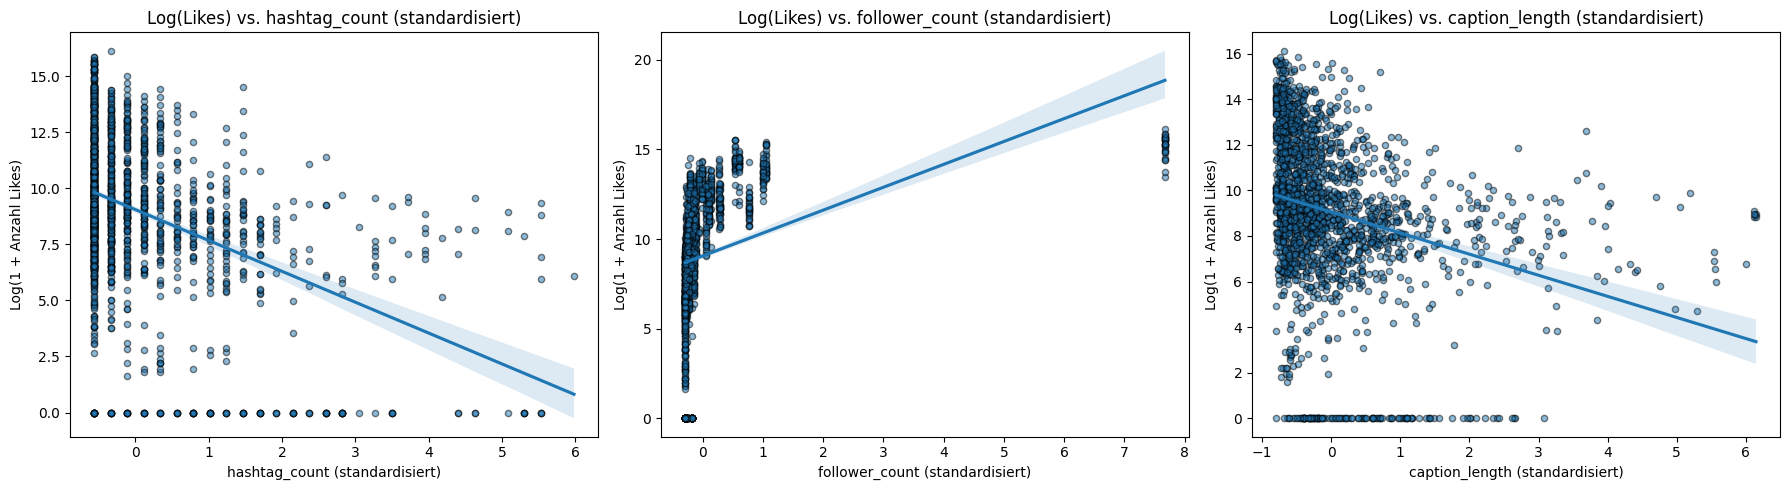

In [8]:
# Korrelationen sortieren und Top-3 Features auswählen
corrs_std = df_std.corr()['likes_log'].abs().sort_values(ascending=False)
top_features_std = [col for col in corrs_std.index if col != 'likes_log'][:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(top_features_std):
    # Regression mit standardisierten Werten 
    sns.regplot(
        x=feature, y='likes_log', data=df_std,
        scatter_kws={'s': 20, 'alpha': 0.5, 'edgecolor': 'k' },
        ax=axes[i]
    )
    axes[i].set_title(f'Log(Likes) vs. {feature} (standardisiert)')
    axes[i].set_xlabel(f'{feature} (standardisiert)')
    axes[i].set_ylabel('Log(1 + Anzahl Likes)')
plt.tight_layout()
plt.show()

### Beziehung kategorialer Merkmale zu likes_log

- Das Ziel ist es, ein besseres Verständnis dafür zu entwickeln, wie verschiedene kategoriale Merkmale mit der Zielvariablen (likes_log) zusammenhängen. 

Durch die Visualisierung (Boxplots, Linienplots) kann man sehen, ob bestimmte Kategorien eines Merkmals tendenziell höhere oder niedrigere likes_log-Werte aufweisen. Man kann erste Hypothesen über den Einfluss dieser Merkmale auf die Likes bilden.
Es kann auch helfen zu entscheiden, welche Merkmale potenziell wichtig für ein späteres Vorhersagemodell sind. 

Um die Übersichlichkeit zu erhöhen, wird hour_of_day mit kategorialen Werten dargestellt.

In diesem Code werden die Beziehungen zwischen kategorialen Merkmalen und der Zielvariable likes_log visuell untersucht, nicht über eine numerische Korrelation berechnet.

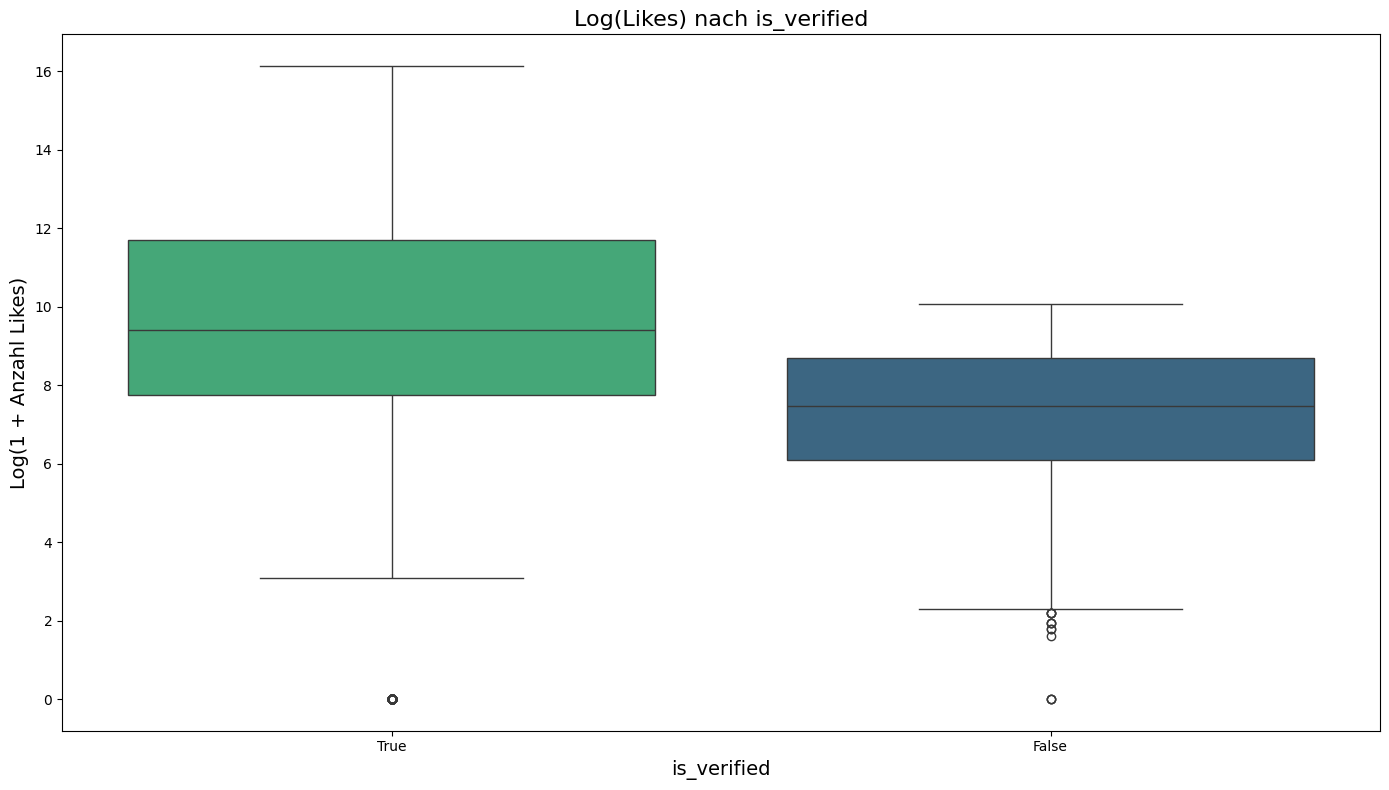

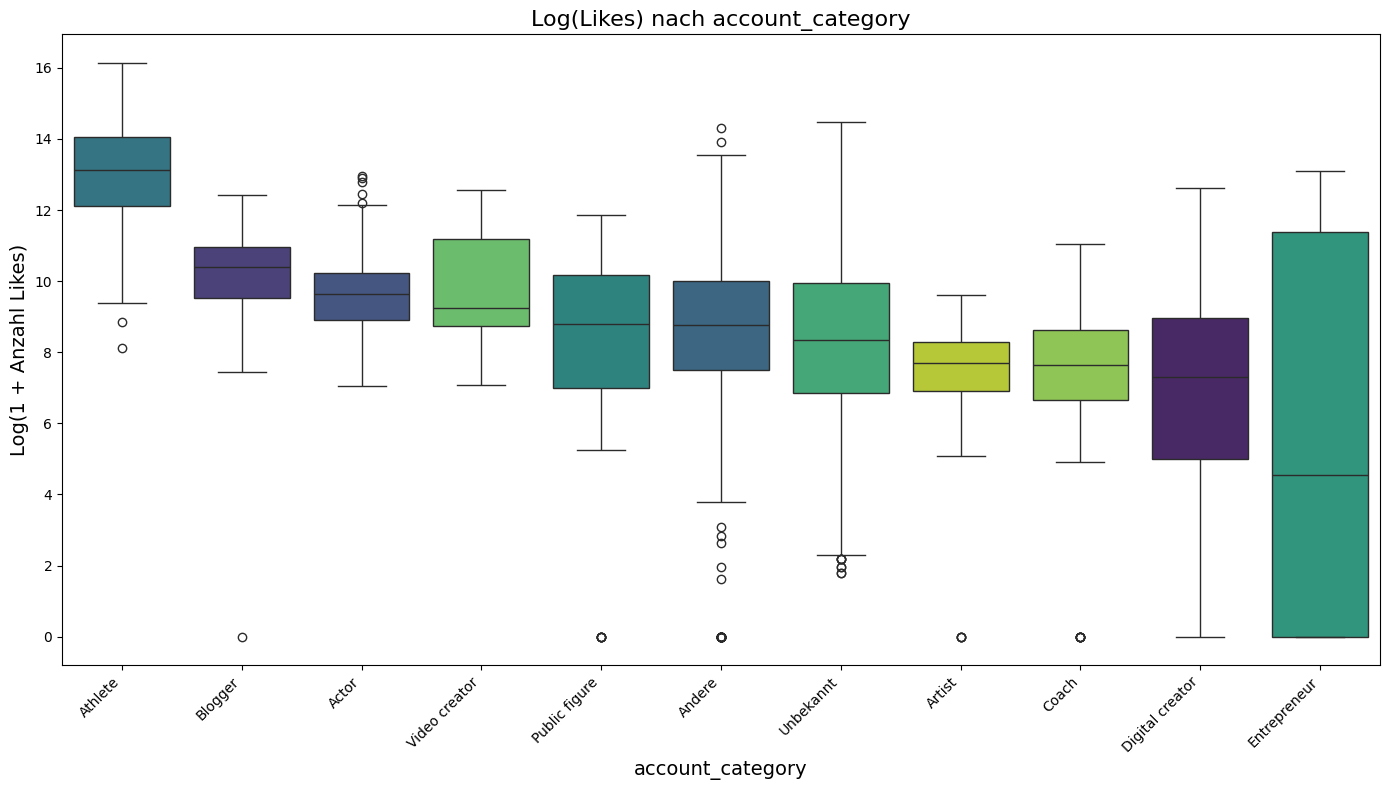

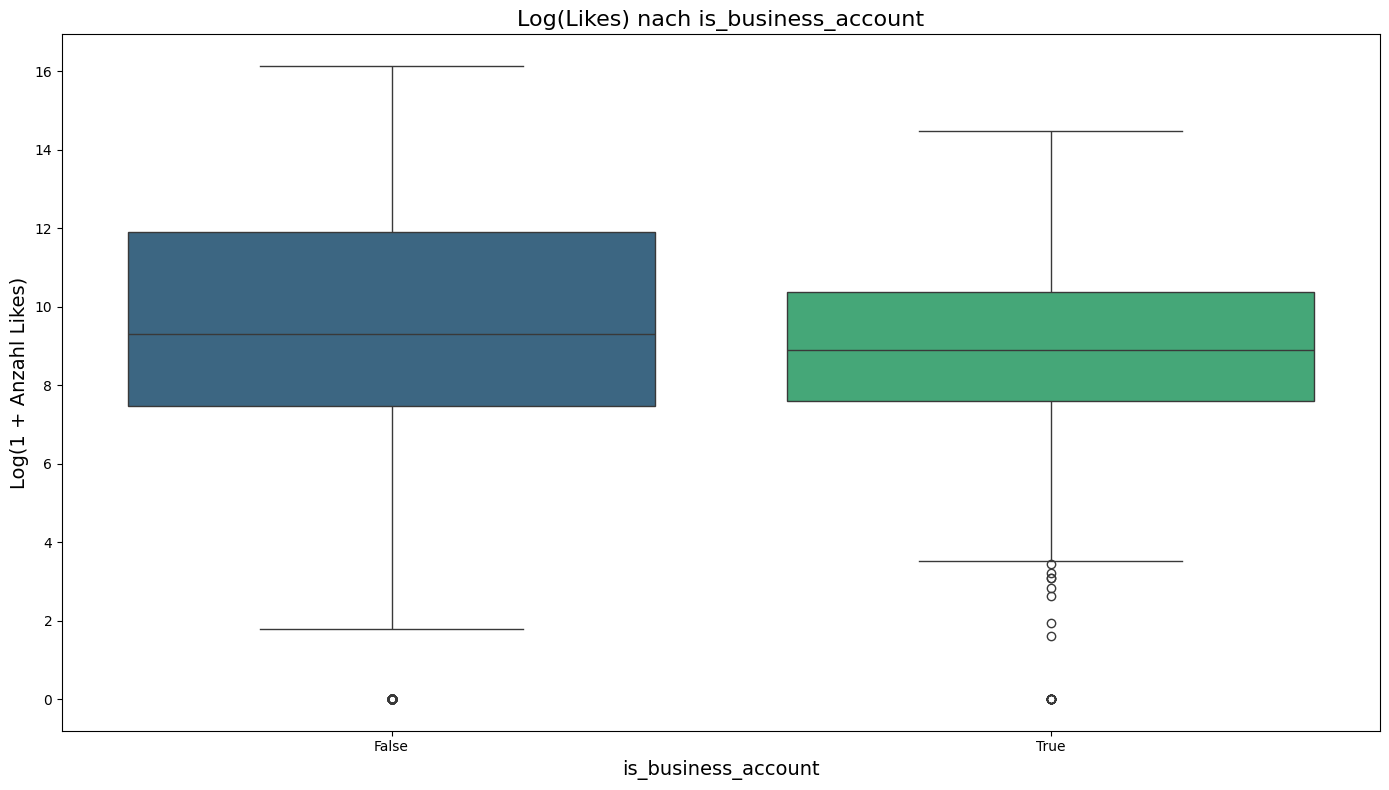

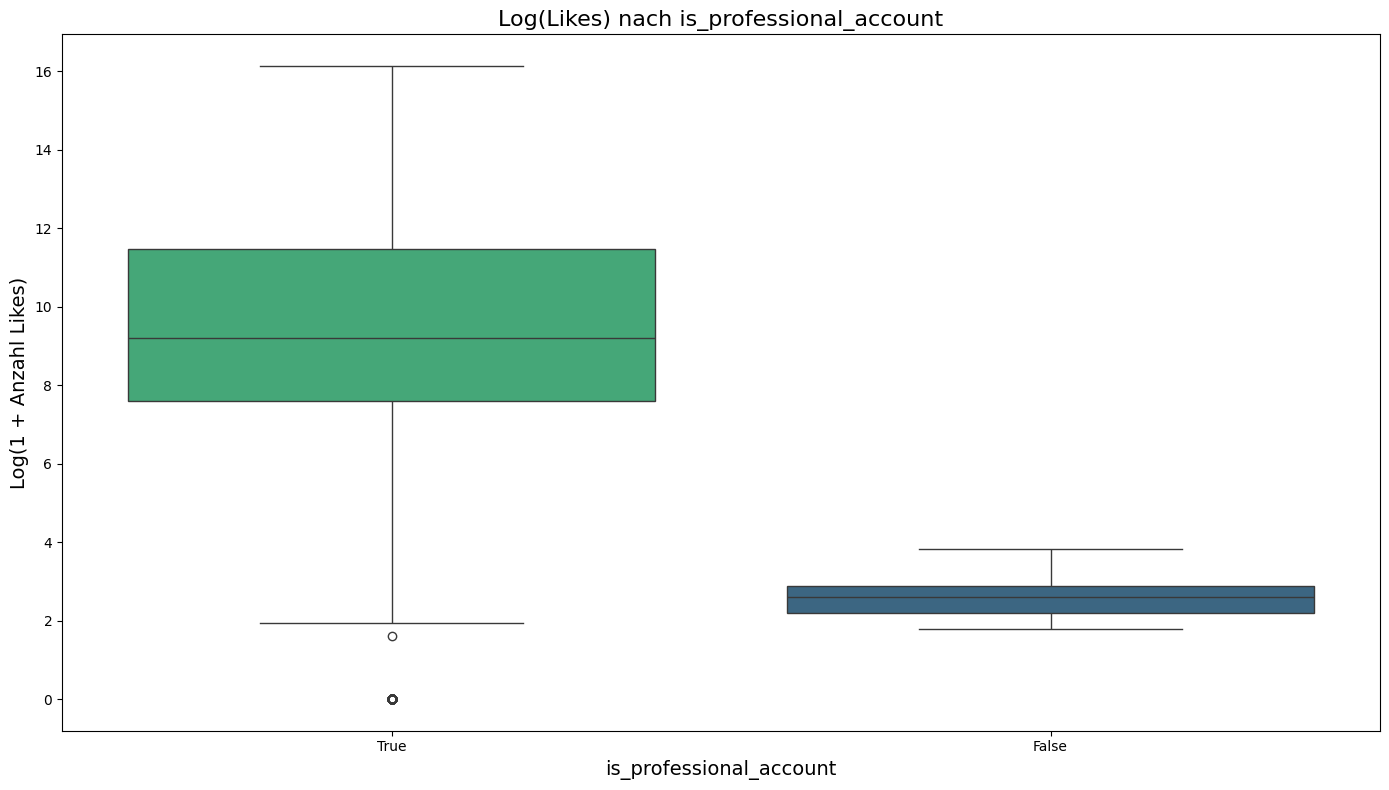

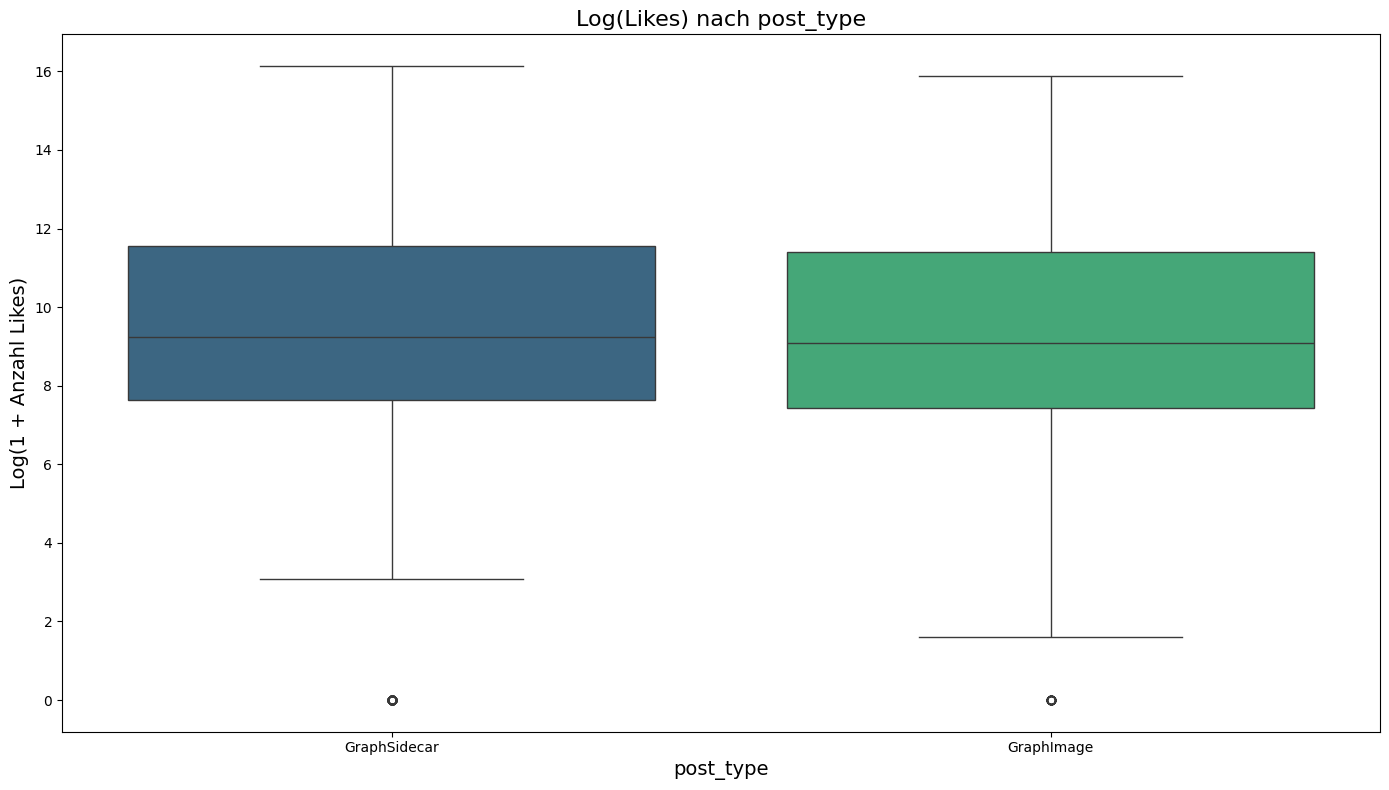

In [9]:
kategoriale_merkmale = [col for col in X.select_dtypes(include=['object', 'bool', 'category']).columns]


for kategorial in kategoriale_merkmale:

    temporaere_plot_df = pd.concat([X[[kategorial]].copy(), y.copy()], axis=1)
    
    plt.figure(figsize=(14, 8))
    
    # Spezialbehandlung für 'account_category'
    if kategorial == 'account_category':
        
        top_n = temporaere_plot_df[kategorial].value_counts().nlargest(10).index # Top 10 Kategorien
        # Alle Kategorien, die nicht zu den Top 10 gehören - werden als 'Andere' zusammengefasst
        temporaere_plot_df[kategorial] = temporaere_plot_df[kategorial].astype(str).apply(lambda x: x if x in top_n else 'Andere')
        order = temporaere_plot_df.groupby(kategorial)['likes_log'].median().sort_values(ascending=False).index
        sns.boxplot(x=kategorial, y='likes_log', data=temporaere_plot_df, order=order, hue=kategorial, palette='viridis', legend=False)
    else:
        # ALLGEMEINER FALL: Für ALLE ANDEREN Merkmale in der Liste "kategoriale_merkmale"

        order = temporaere_plot_df.groupby(kategorial)['likes_log'].median().sort_values(ascending=False).index
        sns.boxplot(x=kategorial, y='likes_log', data=temporaere_plot_df, order=order, hue=kategorial, palette='viridis', legend=False)

    plt.title(f'Log(Likes) nach {kategorial}', fontsize=16)
    plt.xlabel(kategorial, fontsize=14)
    plt.ylabel('Log(1 + Anzahl Likes)', fontsize=14)
    if temporaere_plot_df[kategorial].nunique() > 5 : 
        plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.tight_layout()
    plt.show()


### Interpretation der Ergebnisse:

1. is_verified
    - Verifizierte Accounts haben im Median signifikant höhere Log(Likes)-Werte als nicht verifizierte Accounts. Die Streuung der Likes ist bei verifizierten Accounts ebenfalls größer. Dies legt nahe, dass eine Verifizierung tendenziell mit einer höheren Anzahl an Likes einhergeht.


2. account_category
   - Die Kategorie des Accounts scheint einen deutlichen Einfluss auf die erwarteten Log(Likes) zu haben. Bestimmte Kategorien wie "Athlete" oder potenziell "Entrepreneur" erzielen im Median deutlich höhere Like-Zahlen, während andere wie "Artist" oder "Coach" tendenziell niedrigere Like-Zahlen aufweisen. Die Sortierung nach Median hilft, diese Unterschiede schnell zu erkennen. Die Kategorie "Andere" (falls vorhanden und nicht explizit "Entrepreneur" gemeint ist) zeigt erwartungsgemäß eine hohe Streuung und viele Ausreißer, da sie heterogene Account-Typen zusammenfasst.

3. is_business_account
    - Accounts, die kein Business-Account sind (False), haben im Median tendenziell leicht höhere Log(Likes)-Werte als ausgewiesene Business-Accounts (True). Der Unterschied im Median ist jedoch nicht extrem groß. Beide Gruppen zeigen eine erhebliche Streuung in den Like-Zahlen. Es gibt bei Business-Accounts eine größere Anzahl von Ausreißern im unteren Bereich der Like-Verteilung aufweisen,was bedeuten könnte, dass es zwar einige gut performende Business-Accounts gibt, aber auch eine signifikante Anzahl, die vergleichsweise wenige Likes erhalten.

4. is_professional_account
   - Die Ergebnisse deuten stark darauf hin, dass die Klassifizierung als "Professional Account" ein wichtiger Indikator für höhere Interaktionsraten (Likes) ist. Dies könnte daran liegen, dass professionelle Accounts möglicherweise qualitativ hochwertigeren Content posten, eine größere oder engagiertere Follower-Basis haben oder gezieltere Strategien zur Interaktionssteigerung verfolgen.

5. post_type
    - Der Post-Typ (ob Karussell oder Einzelbild) haben keinen starken, eindeutigen Einfluss auf die durchschnittliche Anzahl der erhaltenen Likes zu haben. Die Performance beider Formate ist im Median und in ihrer Variabilität sehr vergleichbar. 
